In [2]:
import pandas as pd
print(pd.__version__)

3.0.3


## **Series using list**

In [3]:
marks = [22,34,23,12]
sub   = ['maths', 'science','english', 'hindi']
marks_of_subjects = pd.Series(marks,index=sub, name='student-01')
marks_of_subjects

maths      22
science    34
english    23
hindi      12
Name: student-01, dtype: int64

## **Series using Dict**

In [4]:
#creating dict from two given lists
a = dict(zip(sub,marks))
marks_of_subjects = pd.Series(a, name='student-01')
marks_of_subjects

maths      22
science    34
english    23
hindi      12
Name: student-01, dtype: int64

## **Series: methods and attributes**
(also dataframe's common methods and attributes)

In [5]:
#attributes
marks_of_subjects.size, marks_of_subjects.name, marks_of_subjects.dtype, marks_of_subjects.is_unique, pd.Series([1,1,2,3]).is_unique, marks_of_subjects.index, pd.Series(list(range(4))).index, pd.Series([1,2,3,4,5]).index, type(pd.Series([4,5,6]).index), marks_of_subjects.values, type(marks_of_subjects.values)

(4,
 'student-01',
 dtype('int64'),
 True,
 False,
 Index(['maths', 'science', 'english', 'hindi'], dtype='str'),
 RangeIndex(start=0, stop=4, step=1),
 RangeIndex(start=0, stop=5, step=1),
 pandas.RangeIndex,
 array([22, 34, 23, 12]),
 numpy.ndarray)

In [6]:
import csv
import numpy as np
from pathlib import Path

path = Path('csv_files/subs.csv')
if not path.exists():
    path.parent.mkdir(parents=True,exist_ok=True)
    path.touch()


with open (path.resolve(), mode='w') as csvfile: #path.resolve() gives the full path
    fieldname = ['subscribers gained', 'members joined']
    col1 = np.random.randint(20,50,(60,1))
    col2 = np.random.randint(1,9,(60,1))

    cols = np.hstack([col1,col2])
    cols = cols.tolist()

    writer = csv.writer(csvfile)
    writer.writerow(fieldname)
    writer.writerows(cols)

subs = pd.read_csv('csv_files/subs.csv')
subs.head()

,subscribers gained,members joined
0,49,3
1,48,7
2,39,7
3,47,4
4,35,4


In [7]:
type(pd.read_csv('csv_files/subs.csv'))

pandas.DataFrame

In [8]:
path = 'csv_files/subs.csv'
type(pd.read_csv(path).iloc[:,0]), '-'*80, pd.read_csv(path).iloc[:,0].head(),   #notice the 'name' is automatically generated named 'subscribers ganined' which is our column name

(pandas.Series,
 '--------------------------------------------------------------------------------',
 0    49
 1    48
 2    39
 3    47
 4    35
 Name: subscribers gained, dtype: int64)

In [9]:
path = Path('csv_files/aadarsh_runs.csv')

if not path.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
    path.touch()

with open(path.resolve(), mode='w') as csvfile: #path.resolve() outputs the full path
    runs = np.random.randint(0,100,((50,1)))
    matches = np.arange(1,51).reshape((50,1))
    rows = np.concatenate([matches, runs], axis=1)
    rows = rows.tolist()
    writer = csv.writer(csvfile)
    writer.writerow(['match number', 'aadarsh runs'])
    writer.writerows(rows)

runs = pd.read_csv(path.resolve(), index_col='match number')
runs.head()

,aadarsh runs
match number,
1,63
2,72
3,71
4,51
5,88


In [10]:
#convert dataframe to series while fetching from read_csv
type(runs), type(runs.squeeze())

(pandas.DataFrame, pandas.Series)

In [11]:
#since series automatically provides 'name' equivalent to the column name 
runs.squeeze().head()

match number
1    63
2    72
3    71
4    51
5    88
Name: aadarsh runs, dtype: int64

In [12]:
#methods
runs.squeeze().tail()

match number
46    91
47    69
48    53
49    35
50    53
Name: aadarsh runs, dtype: int64

In [13]:
#sample(n): random select 'n' rows
subs.sample(5)

,subscribers gained,members joined
21,40,6
59,48,7
46,45,6
13,46,6
38,28,8


In [14]:
#freq of values
runs.value_counts().head()

aadarsh runs
43              4
35              3
71              2
88              2
49              2
Name: count, dtype: int64

In [15]:
print(runs.sort_values(by='aadarsh runs', ascending=False).head()) #since its a dataframe, 'by' argument was reqd.
print('-'*80)
print(runs.squeeze().sort_values(ascending=True, inplace=False).head()) #series, hence by deafult sorted by the only col. (value col)
#inplace=True makes the changes in the original dataframe/series

              aadarsh runs
match number              
9                       98
43                      98
10                      97
19                      92
46                      91
--------------------------------------------------------------------------------
match number
44     7
21    13
36    14
15    17
29    18
Name: aadarsh runs, dtype: int64


In [16]:
subs.sort_index(ascending=False).head()

,subscribers gained,members joined
59,48,7
58,49,8
57,26,3
56,30,5
55,39,7


In [17]:
import csv

# Define header and data rows
fields = ['Name', 'Branch', 'Year', 'CGPA', 'Remarks']
rows = [
    ['Nikhil', 'COE', '2', '9.0', None],
    ['Sanchit', 'COE', '2', '9.1', 'Good'],
    ['Aditya', 'IT', '2', '9.3', None],
    ['Sagar', 'SE', '1', '9.5', None],
    ['Prateek', 'MCE', '3', '7.8', None],
    ['Sahil', 'EP', '2', '9.1', 'Excellent']
]

filename = Path("csv_files/university_records.csv")
if not filename.exists():
    filename.parent.mkdir(parents=True,exist_ok=True)
    filename.touch()

with open(filename.resolve(), 'w') as csvfile:
    csvwriter = csv.writer(csvfile)        # Create writer object
    csvwriter.writerow(fields)             # Write header
    csvwriter.writerows(rows)              # Write multiple rows

uni_records = pd.read_csv(filename.resolve()) #imp. argument:  index_col=''
uni_records

,Name,Branch,Year,CGPA,Remarks
0,Nikhil,COE,2,9.0,NaN
1,Sanchit,COE,2,9.1,Good
2,Aditya,IT,2,9.3,NaN
3,Sagar,SE,1,9.5,NaN
4,Prateek,MCE,3,7.8,NaN
5,Sahil,EP,2,9.1,Excellent


## **Series math methods**
(also common dataframe methods)

In [18]:
#count will count the not NaN values
uni_records.count()

Name       6
Branch     6
Year       6
CGPA       6
Remarks    2
dtype: int64

In [19]:
#sum()
uni_records['CGPA'].sum() / uni_records.size #average

np.float64(1.7933333333333334)

In [20]:
subs.mean(), subs.median(), subs.min(), subs.max(), subs.std(), subs.var()

(subscribers gained    36.433333
 members joined         5.016667
 dtype: float64,
 subscribers gained    36.5
 members joined         5.0
 dtype: float64,
 subscribers gained    21
 members joined         1
 dtype: int64,
 subscribers gained    49
 members joined         8
 dtype: int64,
 subscribers gained    8.747623
 members joined        2.325188
 dtype: float64,
 subscribers gained    76.520904
 members joined         5.406497
 dtype: float64)

In [21]:
subs.describe(),'-'*80, uni_records.describe()

(       subscribers gained  members joined
 count           60.000000       60.000000
 mean            36.433333        5.016667
 std              8.747623        2.325188
 min             21.000000        1.000000
 25%             29.750000        3.000000
 50%             36.500000        5.000000
 75%             45.000000        7.000000
 max             49.000000        8.000000,
 '--------------------------------------------------------------------------------',
            Year      CGPA
 count  6.000000  6.000000
 mean   2.000000  8.966667
 std    0.632456  0.598888
 min    1.000000  7.800000
 25%    2.000000  9.025000
 50%    2.000000  9.100000
 75%    2.000000  9.250000
 max    3.000000  9.500000)

## **Series indexing**

In [22]:
x = pd.Series([3,4,2,5,6,4,3,0,1])
x[0], x[2:6], x[-1:],x[-2:]  #NOTE: x[-1] doesn't work idk why

(np.int64(3),
 2    2
 3    5
 4    6
 5    4
 dtype: int64,
 8    1
 dtype: int64,
 7    0
 8    1
 dtype: int64)

In [23]:
subs[-1:], subs[::2].head(), uni_records[['Name', 'CGPA']],'-'*80, uni_records['Name'][2]

(    subscribers gained  members joined
 59                  48               7,
    subscribers gained  members joined
 0                  49               3
 2                  39               7
 4                  35               4
 6                  46               7
 8                  44               8,
       Name  CGPA
 0   Nikhil   9.0
 1  Sanchit   9.1
 2   Aditya   9.3
 3    Sagar   9.5
 4  Prateek   7.8
 5    Sahil   9.1,
 '--------------------------------------------------------------------------------',
 'Aditya')

In [24]:
y = pd.Series(['A','B','C','D'], index=['a','b','c','d'], name='Capital')
y

a    A
b    B
c    C
d    D
Name: Capital, dtype: str

In [25]:
y['a'], y['a':'c'], y[2:], y[2:3], y[-1:] #NOTE here y[2] is also not working, but y[2:] does

('A',
 a    A
 b    B
 c    C
 Name: Capital, dtype: str,
 c    C
 d    D
 Name: Capital, dtype: str,
 c    C
 Name: Capital, dtype: str,
 d    D
 Name: Capital, dtype: str)

In [26]:
y[['b','d','a']] #fancy indexing

b    B
d    D
a    A
Name: Capital, dtype: str

In [27]:
y[1] = 'Z' #creates a new index value, '1' since the index is not present (like a dict)
y

a    A
b    B
c    C
d    D
1    Z
Name: Capital, dtype: str

In [28]:
z = pd.Series([4,3,5,3])
z[1] = 2
z[6] = 4 #creates a new index (like a dict)
z[2:6] = 100 #even though we dont have an index 4 here, the slicing works
z, z[2:4] #works

(0      4
 1      2
 2    100
 3    100
 6    100
 dtype: int64,
 2    100
 3    100
 dtype: int64)

In [29]:
z[[3,6]] = 50
z

0      4
1      2
2    100
3     50
6     50
dtype: int64

## **Series with python functionalities**

(basically, python builtin function works well with pandas)

In [30]:
# len/type/dir/sorted/max/min
len(subs), type(subs), subs['subscribers gained'][-2:], min(subs['subscribers gained']) # dir(subs) # sorted(subs['members joined']) 

(60,
 pandas.DataFrame,
 58    49
 59    48
 Name: subscribers gained, dtype: int64,
 21)

In [31]:
a = runs['aadarsh runs'][-3:]
b = marks_of_subjects
list(a), dict(a), list(b), dict(b)

([53, 35, 53],
 {48: np.int64(53), 49: np.int64(35), 50: np.int64(53)},
 [22, 34, 23, 12],
 {'maths': np.int64(22),
  'science': np.int64(34),
  'english': np.int64(23),
  'hindi': np.int64(12)})

In [32]:
#membership operator 
print('english' in marks_of_subjects) #works on keys by default like python dict
print(22 in marks_of_subjects.values)

True
True


In [33]:
#Arithmetic operators (an example of Broadcasting)
40 - marks_of_subjects, (marks_of_subjects/40)*100

(maths      18
 science     6
 english    17
 hindi      28
 Name: student-01, dtype: int64,
 maths      55.0
 science    85.0
 english    57.5
 hindi      30.0
 Name: student-01, dtype: float64)

In [34]:
#relational operators
sg = subs['subscribers gained']
m = marks_of_subjects
m >= 30, m[m >= 30], sg[sg >= 46]

(maths      False
 science     True
 english    False
 hindi      False
 Name: student-01, dtype: bool,
 science    34
 Name: student-01, dtype: int64,
 0     49
 1     48
 3     47
 6     46
 13    46
 14    48
 15    48
 18    48
 26    48
 29    46
 30    46
 41    48
 58    49
 59    48
 Name: subscribers gained, dtype: int64)

## **Plotting Graphs with Series**

<Axes: >

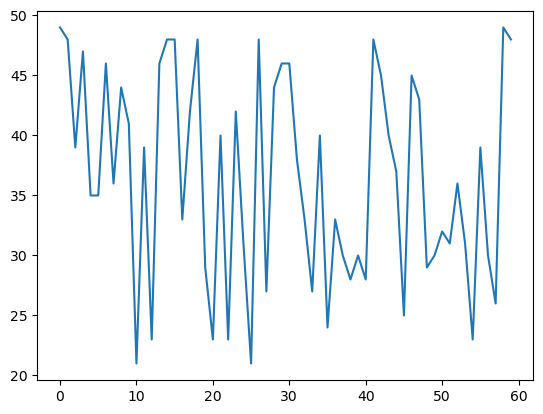

In [ ]:
subs['subscribers gained'].plot() #x:index/keys, y:values

<Axes: xlabel='aadarsh runs', ylabel='# of times'>

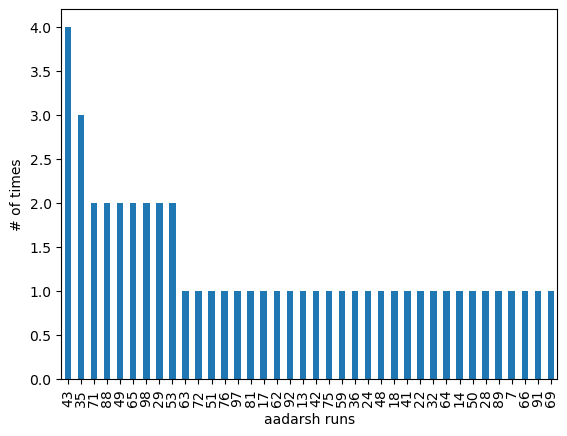

In [57]:
runs['aadarsh runs'].value_counts().plot(kind='bar', ylabel='# of times')

In [36]:
a = [1, 7, 2]

#Series and DataFrame
myvar = pd.Series(a, index = ['a','b','c'])
myvar_df = pd.DataFrame(myvar,columns=['numbersss'])

print(myvar)
print(myvar_df)
print(type(myvar))
print(type(myvar_df))

a    1
b    7
c    2
dtype: int64
   numbersss
a          1
b          7
c          2
<class 'pandas.Series'>
<class 'pandas.DataFrame'>


In [37]:
dates = pd.date_range('20250918', periods=6)
dates, type(dates)

(DatetimeIndex(['2025-09-18', '2025-09-19', '2025-09-20', '2025-09-21',
                '2025-09-22', '2025-09-23'],
               dtype='datetime64[us]', freq='D'),
 pandas.DatetimeIndex)

In [38]:
import numpy as np

df = pd.DataFrame(np.random.randn(6,4), index=dates, columns=list("ABCD"))
df

,A,B,C,D
2025-09-18,-0.535896,-1.363744,-0.937600,-1.504563
2025-09-19,0.976636,0.962735,0.758542,-0.200688
2025-09-20,-0.192355,0.043638,-1.091519,0.408500
2025-09-21,0.196641,-0.698693,0.985469,1.359376
2025-09-22,0.318021,0.823442,-1.150769,-0.345317
2025-09-23,-1.054252,0.425165,-0.868331,1.434758


In [39]:
li = list(range(4))
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=li, dtype="float32"),
        "D": list([(3,),4,'s',.4]),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
        "PresentDate": pd.Series(pd.date_range('20250918', periods=len(li)))
    }
)
df2, df2.index, df2.columns

(     A          B    C     D      E    F PresentDate
 0  1.0 2013-01-02  1.0  (3,)   test  foo  2025-09-18
 1  1.0 2013-01-02  1.0     4  train  foo  2025-09-19
 2  1.0 2013-01-02  1.0     s   test  foo  2025-09-20
 3  1.0 2013-01-02  1.0   0.4  train  foo  2025-09-21,
 Index([0, 1, 2, 3], dtype='int64'),
 Index(['A', 'B', 'C', 'D', 'E', 'F', 'PresentDate'], dtype='str'))

In [40]:
df2.to_numpy(),'-'*80, df2.dtypes,'-'*80, df2.describe()

(array([[1.0, Timestamp('2013-01-02 00:00:00'), 1.0, (3,), 'test', 'foo',
         Timestamp('2025-09-18 00:00:00')],
        [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 4, 'train', 'foo',
         Timestamp('2025-09-19 00:00:00')],
        [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 's', 'test', 'foo',
         Timestamp('2025-09-20 00:00:00')],
        [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 0.4, 'train', 'foo',
         Timestamp('2025-09-21 00:00:00')]], dtype=object),
 '--------------------------------------------------------------------------------',
 A                     float64
 B              datetime64[us]
 C                     float32
 D                      object
 E                    category
 F                         str
 PresentDate    datetime64[us]
 dtype: object,
 '--------------------------------------------------------------------------------',
          A                    B    C          PresentDate
 count  4.0                    4  4.0                

In [41]:
df,'-'*80, df['A'],'-'*80, df.A,'-'*80, df.A[0:2], '-'*80, df[0:2], '-'*80, df[['A','B']][0:2]

(                   A         B         C         D
 2025-09-18 -0.535896 -1.363744 -0.937600 -1.504563
 2025-09-19  0.976636  0.962735  0.758542 -0.200688
 2025-09-20 -0.192355  0.043638 -1.091519  0.408500
 2025-09-21  0.196641 -0.698693  0.985469  1.359376
 2025-09-22  0.318021  0.823442 -1.150769 -0.345317
 2025-09-23 -1.054252  0.425165 -0.868331  1.434758,
 '--------------------------------------------------------------------------------',
 2025-09-18   -0.535896
 2025-09-19    0.976636
 2025-09-20   -0.192355
 2025-09-21    0.196641
 2025-09-22    0.318021
 2025-09-23   -1.054252
 Freq: D, Name: A, dtype: float64,
 '--------------------------------------------------------------------------------',
 2025-09-18   -0.535896
 2025-09-19    0.976636
 2025-09-20   -0.192355
 2025-09-21    0.196641
 2025-09-22    0.318021
 2025-09-23   -1.054252
 Freq: D, Name: A, dtype: float64,
 '--------------------------------------------------------------------------------',
 2025-09-18   -0.53589

In [42]:
df.loc[dates[0]], df.loc[dates[:2]], df.loc[:,['A','B']]

(A   -0.535896
 B   -1.363744
 C   -0.937600
 D   -1.504563
 Name: 2025-09-18 00:00:00, dtype: float64,
                    A         B         C         D
 2025-09-18 -0.535896 -1.363744 -0.937600 -1.504563
 2025-09-19  0.976636  0.962735  0.758542 -0.200688,
                    A         B
 2025-09-18 -0.535896 -1.363744
 2025-09-19  0.976636  0.962735
 2025-09-20 -0.192355  0.043638
 2025-09-21  0.196641 -0.698693
 2025-09-22  0.318021  0.823442
 2025-09-23 -1.054252  0.425165)

In [43]:
df.loc['20250918':'20250921'],df.at[dates[0], 'A']

(                   A         B         C         D
 2025-09-18 -0.535896 -1.363744 -0.937600 -1.504563
 2025-09-19  0.976636  0.962735  0.758542 -0.200688
 2025-09-20 -0.192355  0.043638 -1.091519  0.408500
 2025-09-21  0.196641 -0.698693  0.985469  1.359376,
 np.float64(-0.5358959326728464))

In [44]:
#first parameter is for row, second is for columns
df.iloc[[1,4],[0,3]], df.iloc[1:4, 0:3], df.iloc[1:4], df.iloc[2,2]

(                   A         D
 2025-09-19  0.976636 -0.200688
 2025-09-22  0.318021 -0.345317,
                    A         B         C
 2025-09-19  0.976636  0.962735  0.758542
 2025-09-20 -0.192355  0.043638 -1.091519
 2025-09-21  0.196641 -0.698693  0.985469,
                    A         B         C         D
 2025-09-19  0.976636  0.962735  0.758542 -0.200688
 2025-09-20 -0.192355  0.043638 -1.091519  0.408500
 2025-09-21  0.196641 -0.698693  0.985469  1.359376,
 np.float64(-1.0915186720680936))

In [45]:
df, df[df['A']>0], df[df>1.2]

(                   A         B         C         D
 2025-09-18 -0.535896 -1.363744 -0.937600 -1.504563
 2025-09-19  0.976636  0.962735  0.758542 -0.200688
 2025-09-20 -0.192355  0.043638 -1.091519  0.408500
 2025-09-21  0.196641 -0.698693  0.985469  1.359376
 2025-09-22  0.318021  0.823442 -1.150769 -0.345317
 2025-09-23 -1.054252  0.425165 -0.868331  1.434758,
                    A         B         C         D
 2025-09-19  0.976636  0.962735  0.758542 -0.200688
 2025-09-21  0.196641 -0.698693  0.985469  1.359376
 2025-09-22  0.318021  0.823442 -1.150769 -0.345317,
              A   B   C         D
 2025-09-18 NaN NaN NaN       NaN
 2025-09-19 NaN NaN NaN       NaN
 2025-09-20 NaN NaN NaN       NaN
 2025-09-21 NaN NaN NaN  1.359376
 2025-09-22 NaN NaN NaN       NaN
 2025-09-23 NaN NaN NaN  1.434758)

In [46]:
dfc = df.copy()

dfc['E'] = [3,4,3,5,4,5]
dfc[dfc['E'].isin([3,5])], dfc[dfc['E'].isin([4])]


(                   A         B         C         D  E
 2025-09-18 -0.535896 -1.363744 -0.937600 -1.504563  3
 2025-09-20 -0.192355  0.043638 -1.091519  0.408500  3
 2025-09-21  0.196641 -0.698693  0.985469  1.359376  5
 2025-09-23 -1.054252  0.425165 -0.868331  1.434758  5,
                    A         B         C         D  E
 2025-09-19  0.976636  0.962735  0.758542 -0.200688  4
 2025-09-22  0.318021  0.823442 -1.150769 -0.345317  4)